# Baseline: Regressão Logística

> Objetivo: treinar um modelo simples de regressão logística e avaliar desempenho no conjunto de teste.

## 1) Importação de bibliotecas e leitura dos dados


In [68]:
# importações de bibliotecas
import pandas as pd
import numpy as np
import sklearn as sk
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_predict, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_fscore_support
    )
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

ortho_clean = pd.read_csv('ortho_eda_clean.csv')

#2) Preparação dos dados

In [69]:
# Definir preditores/target
X = ortho_clean.drop('mudanca_CPAK', axis=1)
y = ortho_clean['mudanca_CPAK']

# One-Hot Encoding como temos variáveis categóricas, codificamos antes de todos os testes/modelos
cols_ohe = [c for c in ['Grupo_pre', 'Sexo'] if c in X.columns]
X = pd.get_dummies(X, columns=cols_ohe, drop_first=True)




# Split estratificado(stratify = y) dos dados em treino e teste de forma
# a garantir a mesma proporção de classes em ambos os conjuntos,
# evitando viés na avaliação do modelo.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# 3) Baseline de Regressão Logistica

In [70]:
# Treino do baseline com Regressão Logística
clf_LR = LogisticRegression(random_state=42)
clf_LR = clf_LR.fit(X_train, y_train)

# Previsões no conjunto de teste
y_pred_LR = clf_LR.predict(X_test)
y_pred_LR_prob = clf_LR.predict_proba(X_test)
print(y_pred_LR_prob)
print(y_pred_LR)

[[9.94280849e-01 5.71915082e-03]
 [9.95761608e-01 4.23839168e-03]
 [9.99799616e-01 2.00383568e-04]
 [9.64181033e-01 3.58189674e-02]
 [9.93979748e-01 6.02025181e-03]
 [9.92111223e-01 7.88877662e-03]
 [9.61981518e-01 3.80184821e-02]
 [9.96239500e-01 3.76049980e-03]
 [2.37091161e-01 7.62908839e-01]
 [8.40136888e-01 1.59863112e-01]
 [9.99692221e-01 3.07779428e-04]
 [8.77927885e-01 1.22072115e-01]
 [9.95861054e-01 4.13894628e-03]
 [9.99426162e-01 5.73838361e-04]
 [9.98069354e-01 1.93064622e-03]
 [9.97777568e-01 2.22243161e-03]
 [8.73780693e-01 1.26219307e-01]
 [9.93804256e-01 6.19574424e-03]
 [9.99987188e-01 1.28119849e-05]
 [9.99085768e-01 9.14232412e-04]
 [9.74398693e-01 2.56013074e-02]
 [9.99950168e-01 4.98318073e-05]
 [5.67166074e-01 4.32833926e-01]
 [9.83084319e-01 1.69156806e-02]
 [9.40510352e-01 5.94896483e-02]
 [9.95393647e-01 4.60635323e-03]
 [9.85869253e-01 1.41307469e-02]
 [9.96991343e-01 3.00865712e-03]
 [9.87920528e-01 1.20794723e-02]
 [2.19381638e-01 7.80618362e-01]
 [9.265353

c:\Users\Eduardo\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


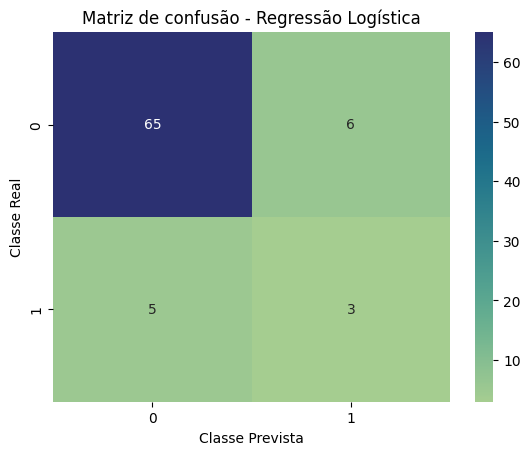

In [71]:
# Matriz de confusão do baseline (Regressão Logística)
c_matrix_LR = confusion_matrix(y_test, y_pred_LR)

# Visualização da matriz de confusão
sns.heatmap(c_matrix_LR, annot=True, fmt='d', cmap='crest')
plt.xlabel('Classe Prevista')
plt.ylabel('Classe Real')

plt.title('Matriz de confusão - Regressão Logística')
plt.show()

In [72]:
# Relatório de classificação do baseline
print(classification_report(y_test, y_pred_LR))

# Área sob a curva ROC (AUC)
auc = roc_auc_score(y_test, y_pred_LR)
print('AUC:', auc)

              precision    recall  f1-score   support

           0       0.93      0.92      0.92        71
           1       0.33      0.38      0.35         8

    accuracy                           0.86        79
   macro avg       0.63      0.65      0.64        79
weighted avg       0.87      0.86      0.86        79

AUC: 0.6452464788732395


In [73]:
# Validação cruzada (Stratified K-fold) para estimar generalização
pred = cross_val_predict(
    clf_LR,
    X,
    y,
    cv=sk.model_selection.StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
 )
print(classification_report(y, pred, digits=4))



              precision    recall  f1-score   support

           0     0.9032    0.9492    0.9256       236
           1     0.1429    0.0769    0.1000        26

    accuracy                         0.8626       262
   macro avg     0.5230    0.5130    0.5128       262
weighted avg     0.8278    0.8626    0.8437       262



c:\Users\Eduardo\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Eduardo\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please als

In [74]:
#coefientes do modelo para análise de importância das features

coef_LR = pd.DataFrame({
    'Variavel': X_train.columns,
    'Coeficiente': clf_LR.coef_[0]
}).sort_values(by='Coeficiente', key=abs, ascending=False)

coef_LR.head(10)

,Variavel,Coeficiente
14,Grupo_pre_5,0.480503
11,Grupo_pre_2,0.475860
12,Grupo_pre_3,-0.436021
13,Grupo_pre_4,-0.391907
8,WR_0,0.192981
3,IMC,-0.162843
7,WD_0,-0.151686
0,Idade,-0.108729
16,Grupo_pre_7,-0.104127
5,EVA_0,0.103426


# 4) teste de redundancia de variaveis

Nesta secção avaliamos se algumas variáveis estão a representar a mesma informação e se podem ser removidas sem perda relevante de desempenho. Na analise exploratória de dados verificou-se a existência de variaveis que eram altamente correlacionadas entre si 

- Comparação 1: WT_0 versus os seus componentes (WR_0, WD_0 e WAtotal_0)
- Comparação 2: IMC versus variáveis de base (Peso e Altura_cm)

Objetivo: identificar a forma mais simples de representar os dados, reduzindo redundância e mantendo qualidade preditiva.

# 4.1) WT_0 vs os seus componentes

WT_0 é composto pela adição dos seus componentes (WR_0, WD_0 e WAtotal_0)

Avaliação da remoção da variavel WT_0:

c:\Users\Eduardo\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Eduardo\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please als

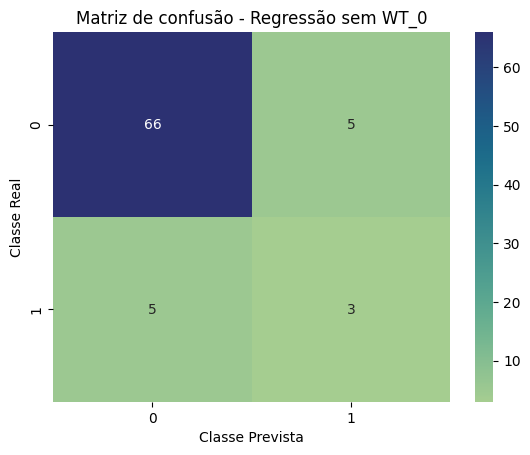

              precision    recall  f1-score   support

           0       0.93      0.93      0.93        71
           1       0.38      0.38      0.38         8

    accuracy                           0.87        79
   macro avg       0.65      0.65      0.65        79
weighted avg       0.87      0.87      0.87        79

AUC sem WT_0: 0.6522887323943661
=== Stratified K-fold (sem WT_0) ===
              precision    recall  f1-score   support

           0     0.9106    0.9492    0.9295       236
           1     0.2500    0.1538    0.1905        26

    accuracy                         0.8702       262
   macro avg     0.5803    0.5515    0.5600       262
weighted avg     0.8450    0.8702    0.8561       262



In [75]:
# preparar os dados para treinar o modelo sem WT_0
x_train_sem_WT0 = X_train.drop('WT_0', axis=1)
x_test_sem_WT0 = X_test.drop('WT_0', axis=1)

# Treino do modelo sem WT_0
clf_LR_sem_WT0 = LogisticRegression(random_state=42)
clf_LR_sem_WT0 = clf_LR_sem_WT0.fit(x_train_sem_WT0, y_train)

# previões
y_pred_LR_sem_WT0 = clf_LR_sem_WT0.predict(x_test_sem_WT0)

# k-fold estratificado para o modelo sem WT_0
pred_cross_sem_WT0 = cross_val_predict(
    clf_LR_sem_WT0,
    X.drop('WT_0', axis=1),
    y,
    cv=sk.model_selection.StratifiedKFold(n_splits=5, shuffle=True, random_state=42)    
)

#avaliação de métricas para o modelo sem WT_0

#matriz de confusao para o modelo sem WT_0
confusion_sem_WT0 = confusion_matrix(y_test, y_pred_LR_sem_WT0)
sns.heatmap(confusion_sem_WT0, annot=True, fmt='d', cmap='crest')
plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")
plt.title("Matriz de confusão - Regressão sem WT_0")
plt.show()

#curva ROC e AUC para o modelo sem WT_0
print(classification_report(y_test, y_pred_LR_sem_WT0))
auc_sem_WT0 = roc_auc_score(y_test, y_pred_LR_sem_WT0)
print("AUC sem WT_0:", auc_sem_WT0)

# k-fold estratificado para o modelo sem WT_0
print("=== Stratified K-fold (sem WT_0) ===")
print(classification_report(y, pred_cross_sem_WT0, digits=4))

Avaliação da remoção dos componentes WR_0, WD_0 e WATotal_0

c:\Users\Eduardo\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Eduardo\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please als

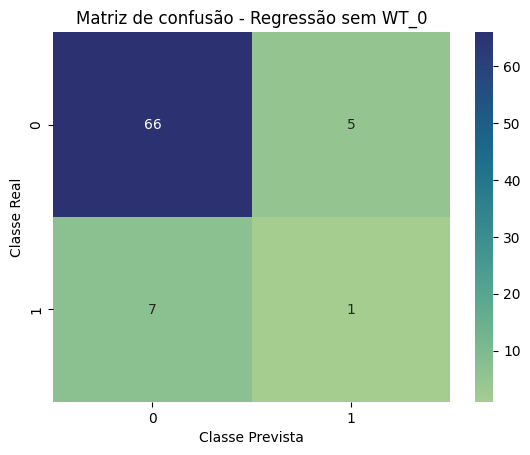

              precision    recall  f1-score   support

           0       0.90      0.93      0.92        71
           1       0.17      0.12      0.14         8

    accuracy                           0.85        79
   macro avg       0.54      0.53      0.53        79
weighted avg       0.83      0.85      0.84        79

AUC sem componentes: 0.5272887323943662
=== Stratified K-fold (sem componentes) ===
              precision    recall  f1-score   support

           0     0.9036    0.9534    0.9278       236
           1     0.1538    0.0769    0.1026        26

    accuracy                         0.8664       262
   macro avg     0.5287    0.5152    0.5152       262
weighted avg     0.8292    0.8664    0.8459       262



In [76]:
# avaliação sem os componentes
# preparar os dados para treinar o modelo sem WR_0, WD_0 e WATotal_0
x_train_sem_comp = X_train.drop(['WR_0', 'WD_0', 'WAtotal_0'], axis=1)
x_test_sem_comp = X_test.drop(['WR_0', 'WD_0', 'WAtotal_0'], axis=1)

# Treino do modelo sem WT_0
clf_LR_sem_comp = LogisticRegression(random_state=42)
clf_LR_sem_comp = clf_LR_sem_comp.fit(x_train_sem_comp, y_train)

# previsões
y_pred_LR_sem_comp = clf_LR_sem_comp.predict(x_test_sem_comp)

# k-fold estratificado para o modelo sem WT_0
pred_cross_sem_comp = cross_val_predict(
    clf_LR_sem_comp,
    X.drop(['WR_0', 'WD_0', 'WAtotal_0'], axis=1),
    y,
    cv=sk.model_selection.StratifiedKFold(n_splits=5, shuffle=True, random_state=42)    
)

# avaliação de métricas para o modelo sem os componentes

# matriz de confusão para o modelo sem os componentes
confusion_sem_comp = confusion_matrix(y_test, y_pred_LR_sem_comp)
sns.heatmap(confusion_sem_comp, annot=True, fmt='d', cmap='crest')
plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")
plt.title("Matriz de confusão - Regressão sem WT_0")
plt.show()

# curva ROC e AUC para o modelo sem os componentes
print(classification_report(y_test, y_pred_LR_sem_comp))
auc_sem_comp = roc_auc_score(y_test, y_pred_LR_sem_comp)
print("AUC sem componentes:", auc_sem_comp)

# K-fold estratificado para o modelo sem os componentes
print("=== Stratified K-fold (sem componentes) ===")
print(classification_report(y, pred_cross_sem_comp, digits=4))


Após remoção de WT_0 verificamos uma melhoria das métricas, mesmo após cross validation com k-fold estratificado, quando removemos os compentnes, temos perda de performance.

Podemos considerar remover WT_0 no modelo final 

# 4.2) IMc vs Peso/Altura_cm

c:\Users\Eduardo\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Eduardo\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please als

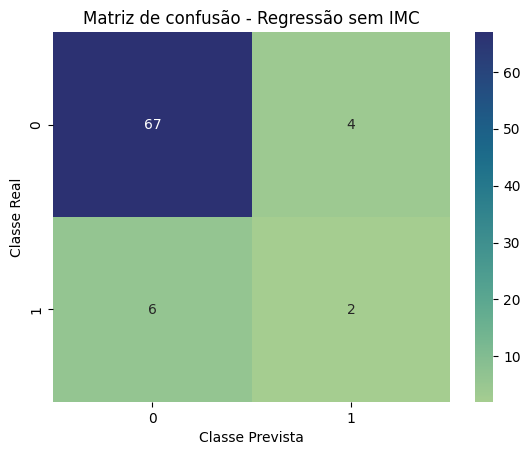

              precision    recall  f1-score   support

           0       0.92      0.94      0.93        71
           1       0.33      0.25      0.29         8

    accuracy                           0.87        79
   macro avg       0.63      0.60      0.61        79
weighted avg       0.86      0.87      0.87        79

AUC sem IMC: 0.5968309859154929
=== Stratified K-fold (sem IMC) ===
              precision    recall  f1-score   support

           0     0.9084    0.9661    0.9363       236
           1     0.2727    0.1154    0.1622        26

    accuracy                         0.8817       262
   macro avg     0.5905    0.5407    0.5493       262
weighted avg     0.8453    0.8817    0.8595       262



In [77]:
# avaliação sem o IMC
# preparar os dados para treinar o modelo sem IMC
x_train_sem_IMC = X_train.drop(['IMC'], axis=1)
x_test_sem_IMC = X_test.drop(['IMC'], axis=1)

# Treino do modelo sem IMC
clf_LR_sem_IMC = LogisticRegression(random_state=42)
clf_LR_sem_IMC = clf_LR_sem_IMC.fit(x_train_sem_IMC, y_train)

# previsões
y_pred_LR_sem_IMC = clf_LR_sem_IMC.predict(x_test_sem_IMC)

# k-fold estratificado para o modelo sem IMC
pred_cross_sem_IMC = cross_val_predict(
    clf_LR_sem_IMC,
    X.drop(['IMC'], axis=1),
    y,
    cv=sk.model_selection.StratifiedKFold(n_splits=5, shuffle=True, random_state=42)    
)

# avaliação de métricas para o modelo sem IMC

# matriz de confusão para o modelo sem IMC
confusion_sem_IMC = confusion_matrix(y_test, y_pred_LR_sem_IMC)
sns.heatmap(confusion_sem_IMC, annot=True, fmt='d', cmap='crest')
plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")
plt.title("Matriz de confusão - Regressão sem IMC")
plt.show()

# curva ROC e AUC para o modelo sem IMC
print(classification_report(y_test, y_pred_LR_sem_IMC))
auc_sem_IMC = roc_auc_score(y_test, y_pred_LR_sem_IMC)
print("AUC sem IMC:", auc_sem_IMC)

# K-fold estratificado para o modelo sem IMC
print("=== Stratified K-fold (sem IMC) ===")
print(classification_report(y, pred_cross_sem_IMC, digits=4))


c:\Users\Eduardo\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Eduardo\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please als

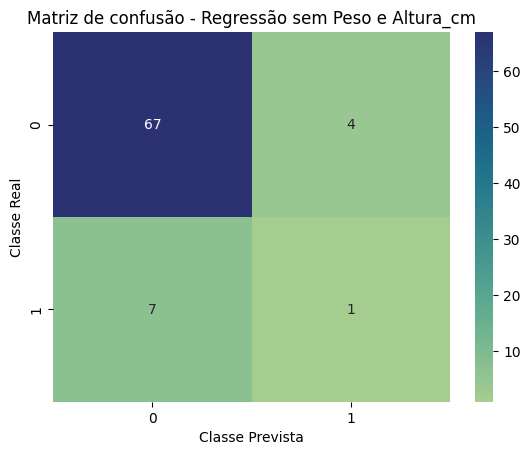

              precision    recall  f1-score   support

           0       0.91      0.94      0.92        71
           1       0.20      0.12      0.15         8

    accuracy                           0.86        79
   macro avg       0.55      0.53      0.54        79
weighted avg       0.83      0.86      0.85        79

AUC sem Peso e Altura_cm: 0.5343309859154929
=== Stratified K-fold (sem Peso e Altura_cm) ===
              precision    recall  f1-score   support

           0     0.9080    0.9619    0.9342       236
           1     0.2500    0.1154    0.1579        26

    accuracy                         0.8779       262
   macro avg     0.5790    0.5386    0.5460       262
weighted avg     0.8427    0.8779    0.8571       262



In [78]:
# avaliação sem Peso e Altura_cm

# preparar os dados para treinar o modelo sem Peso e Altura_cm
x_train_sem_peso_altura = X_train.drop(['Peso', 'Altura_cm'], axis=1)
x_test_sem_peso_altura = X_test.drop(['Peso', 'Altura_cm'], axis=1)

# Treino do modelo sem Peso e Altura_cm
clf_LR_sem_peso_altura = LogisticRegression(random_state=42)
clf_LR_sem_peso_altura = clf_LR_sem_peso_altura.fit(x_train_sem_peso_altura, y_train)

# previsões
y_pred_LR_sem_peso_altura = clf_LR_sem_peso_altura.predict(x_test_sem_peso_altura)

# k-fold estratificado para o modelo sem Peso e Altura_cm
pred_cross_sem_peso_altura = cross_val_predict(
    clf_LR_sem_peso_altura,
    X.drop(['Peso', 'Altura_cm'], axis=1),
    y,
    cv=sk.model_selection.StratifiedKFold(n_splits=5, shuffle=True, random_state=42)    
)

# avaliação de métricas para o modelo sem os componentes

# matriz de confusão para o modelo sem os componentes
confusion_sem_peso_altura = confusion_matrix(y_test, y_pred_LR_sem_peso_altura)
sns.heatmap(confusion_sem_peso_altura, annot=True, fmt='d', cmap='crest')
plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")
plt.title("Matriz de confusão - Regressão sem Peso e Altura_cm")
plt.show()

# curva ROC e AUC para o modelo sem os componentes
print(classification_report(y_test, y_pred_LR_sem_peso_altura))
auc_sem_peso_altura = roc_auc_score(y_test, y_pred_LR_sem_peso_altura)
print("AUC sem Peso e Altura_cm:", auc_sem_peso_altura)

# K-fold estratificado para o modelo sem os componentes
print("=== Stratified K-fold (sem Peso e Altura_cm) ===")
print(classification_report(y, pred_cross_sem_peso_altura, digits=4))


Após avaliação chegamos à conclusão que há uma melhoria face ao modelo baseline retirar o IMC. poderemos considerar retirar o IMC dos dados finais.

# 4.3) Remoção simultânea de variaveis compostas para eliminar redundancia

Embora a remoção isolada de cada variável composta possa melhorar algumas métricas, a remoção conjunta de ambas nem sempre se traduz em ganho de desempenho global.

c:\Users\Eduardo\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Eduardo\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please als

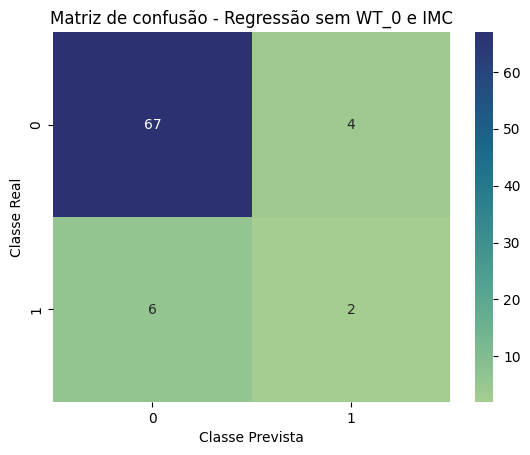

              precision    recall  f1-score   support

           0       0.92      0.94      0.93        71
           1       0.33      0.25      0.29         8

    accuracy                           0.87        79
   macro avg       0.63      0.60      0.61        79
weighted avg       0.86      0.87      0.87        79

AUC sem WT_0 e IMC: 0.5968309859154929
=== Stratified K-fold (sem WT_0) ===
              precision    recall  f1-score   support

           0     0.9120    0.9661    0.9383       236
           1     0.3333    0.1538    0.2105        26

    accuracy                         0.8855       262
   macro avg     0.6227    0.5600    0.5744       262
weighted avg     0.8546    0.8855    0.8661       262



In [79]:
# preparar os dados para treinar o modelo sem WT_0 e IMC
x_train_sem_compostas = X_train.drop(['WT_0','IMC'], axis=1)
x_test_sem_compostas = X_test.drop(['WT_0','IMC'], axis=1)

# Treino do modelo sem WT_0 e IMC
clf_LR_sem_compostas = LogisticRegression(random_state=42)
clf_LR_sem_compostas = clf_LR_sem_compostas.fit(x_train_sem_compostas, y_train)

# previsões
y_pred_LR_sem_compostas = clf_LR_sem_compostas.predict(x_test_sem_compostas)

# k-fold estratificado para o modelo sem WT_0 e IMC
pred_cross_sem_compostas = cross_val_predict(
    clf_LR_sem_compostas,
    X.drop(['WT_0','IMC'], axis=1),
    y,
    cv=sk.model_selection.StratifiedKFold(n_splits=5, shuffle=True, random_state=42)    
)

#avaliação de métricas para o modelo sem WT_0 e IMC

#matriz de confusao para o modelo sem WT_0 e IMC
confusion_sem_compostas = confusion_matrix(y_test, y_pred_LR_sem_compostas)
sns.heatmap(confusion_sem_compostas, annot=True, fmt='d', cmap='crest')
plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")
plt.title("Matriz de confusão - Regressão sem WT_0 e IMC")
plt.show()

#curva ROC e AUC para o modelo sem WT_0 e IMC
print(classification_report(y_test, y_pred_LR_sem_compostas))
auc_sem_compostas = roc_auc_score(y_test, y_pred_LR_sem_compostas)
print("AUC sem WT_0 e IMC:", auc_sem_compostas)

# k-fold estratificado para o modelo sem WT_0
print("=== Stratified K-fold (sem WT_0) ===")
print(classification_report(y, pred_cross_sem_compostas, digits=4))

Após teste de remoção de ambas as variaveis, conclui-se que é possivel que tenha um impacto positivo no desempenho do modelo. 

# 5) afinação de treshold 

Este parâmetro decide o que o modelo deve considerar 0 e 1 e ajuda a apanhar mais verdadeiros positivos(VP)

In [80]:

import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# 1. Probabilidades da classe 1
y_proba = clf_LR.predict_proba(X_test)[:, 1]

# 2. Thresholds a testar
thresholds = np.arange(0.1, 0.6, 0.05)

print("thr | precision | recall | f1")

# 3. Loop
for t in thresholds:
    y_pred = (y_proba >= t).astype(int)
    
    p = precision_score(y_test, y_pred, zero_division=0)
    r = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    print(f"{t:.2f} | {p:.2f} | {r:.2f} | {f1:.2f}")

thr | precision | recall | f1
0.10 | 0.24 | 0.62 | 0.34
0.15 | 0.33 | 0.62 | 0.43
0.20 | 0.31 | 0.50 | 0.38
0.25 | 0.36 | 0.50 | 0.42
0.30 | 0.40 | 0.50 | 0.44
0.35 | 0.40 | 0.50 | 0.44
0.40 | 0.40 | 0.50 | 0.44
0.45 | 0.33 | 0.38 | 0.35
0.50 | 0.33 | 0.38 | 0.35
0.55 | 0.38 | 0.38 | 0.38


Chegamos à conclusão que o melhor threshold para recall é 0.1, mas o mais balanceado é 0.2 aumentando consideravelmente os valores das nossas métricas principais

=== Stratified K-Fold no treino - Regressão Logística Base (threshold=0.15) ===
              precision    recall  f1-score   support

           0     0.9527    0.8545    0.9010       165
           1     0.3143    0.6111    0.4151        18

    accuracy                         0.8306       183
   macro avg     0.6335    0.7328    0.6580       183
weighted avg     0.8899    0.8306    0.8532       183

AUC CV treino: 0.7888888888888889
len(y_test): 79
len(y_pred_test): 79


c:\Users\Eduardo\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Eduardo\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please als

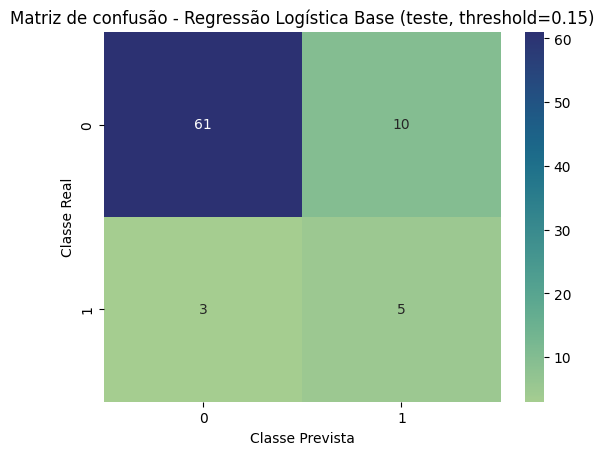

=== Avaliação no teste - Regressão Logística Base (threshold=0.15) ===
              precision    recall  f1-score   support

           0     0.9531    0.8592    0.9037        71
           1     0.3333    0.6250    0.4348         8

    accuracy                         0.8354        79
   macro avg     0.6432    0.7421    0.6692        79
weighted avg     0.8904    0.8354    0.8562        79

AUC teste: 0.7570422535211268


In [89]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

threshold = 0.15

# -----------------------------------
# 1. Validação interna só no treino
# -----------------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pred_proba_cv_train = cross_val_predict(
    clf_LR,
    X_train,
    y_train,
    cv=cv,
    method='predict_proba'
)[:, 1]

pred_cv_train = (pred_proba_cv_train >= threshold).astype(int)

print(f"=== Stratified K-Fold no treino - Regressão Logística Base (threshold={threshold}) ===")
print(classification_report(y_train, pred_cv_train, digits=4))

auc_cv_train = roc_auc_score(y_train, pred_proba_cv_train)
print("AUC CV treino:", auc_cv_train)

# -----------------------------------
# 2. Treinar no treino completo
# -----------------------------------
clf_LR.fit(X_train, y_train)

# -----------------------------------
# 3. Avaliar no teste
# -----------------------------------
y_proba_test = clf_LR.predict_proba(X_test)[:, 1]
y_pred_test = (y_proba_test >= threshold).astype(int)

print("len(y_test):", len(y_test))
print("len(y_pred_test):", len(y_pred_test))

# matriz de confusão no teste
confusion_base = confusion_matrix(y_test, y_pred_test)
sns.heatmap(confusion_base, annot=True, fmt='d', cmap='crest')
plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")
plt.title(f"Matriz de confusão - Regressão Logística Base (teste, threshold={threshold})")
plt.show()

# relatório no teste
print(f"=== Avaliação no teste - Regressão Logística Base (threshold={threshold}) ===")
print(classification_report(y_test, y_pred_test, digits=4))

# AUC no teste
auc_base = roc_auc_score(y_test, y_proba_test)
print("AUC teste:", auc_base)

# 6) Scaler 



=== CV treino - LR + scaler (numéricas) (threshold=0.15) ===
              precision    recall  f1-score   support

           0     0.9514    0.8303    0.8867       165
           1     0.2821    0.6111    0.3860        18

    accuracy                         0.8087       183
   macro avg     0.6167    0.7207    0.6363       183
weighted avg     0.8856    0.8087    0.8375       183

AUC CV treino: 0.7905723905723906


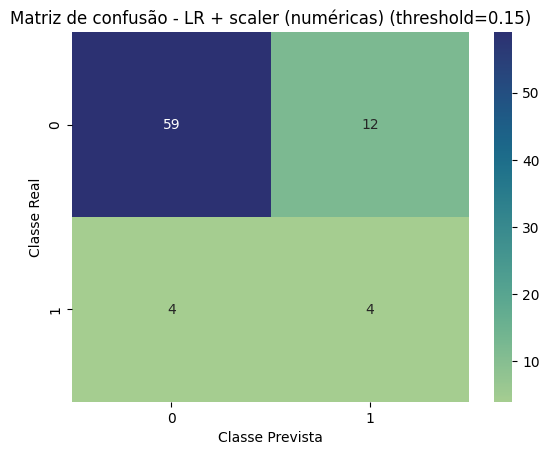

=== Teste - LR + scaler (numéricas) (threshold=0.15) ===
              precision    recall  f1-score   support

           0     0.9365    0.8310    0.8806        71
           1     0.2500    0.5000    0.3333         8

    accuracy                         0.7975        79
   macro avg     0.5933    0.6655    0.6070        79
weighted avg     0.8670    0.7975    0.8252        79

AUC teste: 0.7235915492957747


In [99]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------------
# Configuração
# -----------------------------------
threshold = 0.15

# 
numerical_cols = ['Idade ', 'IMC', 'PM6_0', 'Fle_0', 'WD_0', 'WR_0', 'EVA_0']

# -----------------------------------
# ColumnTransformer
# -----------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols)
    ],
    remainder="passthrough"  # mantém dummies como estão
)

# -----------------------------------
# Pipeline completo
# -----------------------------------
pipe_LR = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

# -----------------------------------
# 1. Validação interna (CV no treino)
# -----------------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pred_proba_cv_train = cross_val_predict(
    pipe_LR,
    X_train,
    y_train,
    cv=cv,
    method='predict_proba'
)[:, 1]

pred_cv_train = (pred_proba_cv_train >= threshold).astype(int)

print(f"=== CV treino - LR + scaler (numéricas) (threshold={threshold}) ===")
print(classification_report(y_train, pred_cv_train, digits=4))

auc_cv_train = roc_auc_score(y_train, pred_proba_cv_train)
print("AUC CV treino:", auc_cv_train)

# -----------------------------------
# 2. Treinar no treino completo
# -----------------------------------
pipe_LR.fit(X_train, y_train)

# -----------------------------------
# 3. Avaliação no teste
# -----------------------------------
y_proba_test = pipe_LR.predict_proba(X_test)[:, 1]
y_pred_test = (y_proba_test >= threshold).astype(int)

# matriz de confusão
confusion = confusion_matrix(y_test, y_pred_test)
sns.heatmap(confusion, annot=True, fmt='d', cmap='crest')
plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")
plt.title(f"Matriz de confusão - LR + scaler (numéricas) (threshold={threshold})")
plt.show()

# relatório
print(f"=== Teste - LR + scaler (numéricas) (threshold={threshold}) ===")
print(classification_report(y_test, y_pred_test, digits=4))

# AUC
auc_test = roc_auc_score(y_test, y_proba_test)
print("AUC teste:", auc_test)

Colunas numéricas a escalar:
['Idade ', 'Peso', 'Altura_cm', 'IMC', 'Fle_0', 'EVA_0', 'PM6_0', 'WD_0', 'WR_0', 'WAtotal_0', 'WT_0']
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Melhores parâmetros:
{'model__C': 10, 'model__class_weight': 'balanced'}
Melhor F1 médio CV:
0.40555555555555556


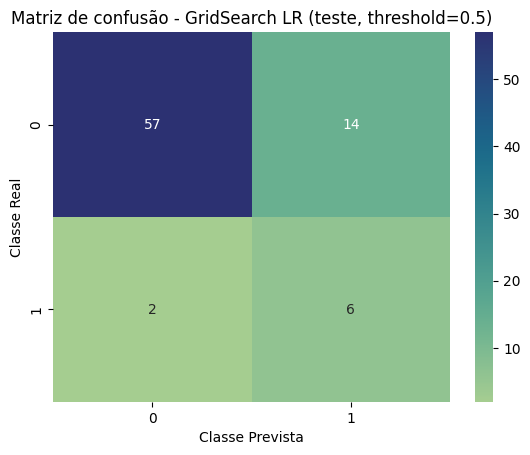

=== Teste - GridSearch LR (threshold=0.5) ===
              precision    recall  f1-score   support

           0     0.9661    0.8028    0.8769        71
           1     0.3000    0.7500    0.4286         8

    accuracy                         0.7975        79
   macro avg     0.6331    0.7764    0.6527        79
weighted avg     0.8986    0.7975    0.8315        79

AUC teste: 0.7746478873239436
   param_model__C param_model__class_weight  mean_test_score  std_test_score  \
7           10.00                  balanced         0.405556        0.178816   
1            0.01                  balanced         0.377662        0.130219   
5            1.00                  balanced         0.376104        0.169054   
6           10.00                      None         0.363333        0.318399   
3            0.10                  balanced         0.343209        0.164663   
4            1.00                      None         0.233333        0.290593   
0            0.01                    

In [104]:
# estudo de hiperparâmetros com GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# -----------------------------------
# Configuração
# -----------------------------------
threshold = 0.5

# identificar colunas numéricas que NÃO são dummies 0/1
numerical_cols = []

for col in X_train.columns:
    if pd.api.types.is_numeric_dtype(X_train[col]):
        vals = set(X_train[col].dropna().unique())
        if not vals.issubset({0, 1}):
            numerical_cols.append(col)

print("Colunas numéricas a escalar:")
print(numerical_cols)

# -----------------------------------
# Preprocessamento
# -----------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols)
    ],
    remainder="passthrough"
)

# -----------------------------------
# Pipeline
# -----------------------------------
pipe_LR = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

# -----------------------------------
# Grid de parâmetros
# -----------------------------------
param_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__class_weight": [None, "balanced"]
}

# -----------------------------------
# Cross-validation
# -----------------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=pipe_LR,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

# -----------------------------------
# Grid search no treino
# -----------------------------------
grid.fit(X_train, y_train)

print("Melhores parâmetros:")
print(grid.best_params_)

print("Melhor F1 médio CV:")
print(grid.best_score_)

# -----------------------------------
# Melhor modelo
# -----------------------------------
best_model = grid.best_estimator_

# -----------------------------------
# Avaliação no teste com threshold=0.15
# -----------------------------------
y_proba_test = best_model.predict_proba(X_test)[:, 1]
y_pred_test = (y_proba_test >= threshold).astype(int)

# matriz de confusão
confusion = confusion_matrix(y_test, y_pred_test)
sns.heatmap(confusion, annot=True, fmt='d', cmap='crest')
plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")
plt.title(f"Matriz de confusão - GridSearch LR (teste, threshold={threshold})")
plt.show()

# relatório
print(f"=== Teste - GridSearch LR (threshold={threshold}) ===")
print(classification_report(y_test, y_pred_test, digits=4))

# AUC
auc_test = roc_auc_score(y_test, y_proba_test)
print("AUC teste:", auc_test)

# resultados completos do grid
resultados_grid = pd.DataFrame(grid.cv_results_)
print(resultados_grid[[
    "param_model__C",
    "param_model__class_weight",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].sort_values("rank_test_score"))